# Atelectasis vs Effusion Classification: ResNet50 + PCA with SVM & KNN

This notebook focuses on binary classification of chest X-ray images from the **NIH Chest X-Ray dataset**, distinguishing between two disease classes:

- **Atelectasis**
- **Effusion**

## Dataset Preparation
- Only **single-label images** are used (multi-label rows excluded).
- Images are processed through a **pretrained ResNet50** (frozen, no fine-tuning).
- ResNet50 outputs **2048-dimensional feature vectors** per image.

## Dimensionality Reduction
- **PCA** applied to reduce dimensionality from 2048 → **974 components**.
- Retains **95% variance** in the reduced feature space.

## Classifiers
1. **Support Vector Machine (SVM)**
   - Kernel: **RBF**
   - Task: Binary classification (Atelectasis vs Effusion)

2. **K-Nearest Neighbors (KNN)**
   - Trained with **K = 1** and **K = 27**

## Evaluation Metrics
- **Classification Report** (precision, recall, F1-score)
- **Confusion Matrix**
- **ROC-AUC Curves**

---



## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import os, glob, cv2
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, accuracy_score 
from sklearn.neighbors import KNeighborsClassifier

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42

2026-04-02 15:56:07.478232: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775145367.705239      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775145367.769759      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775145368.279765      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775145368.279809      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775145368.279812      24 computation_placer.cc:177] computation placer alr

## Load Dataset

In [2]:
CSV_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv"
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head(3)

Shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN


## Select Columns & Map Image Paths

In [3]:
df = df[[
    'Image Index', 'Finding Labels', 'Follow-up #',
    'Patient ID', 'Patient Age', 'Patient Gender', 'View Position'
]].copy()

df.columns = [
    'image_path', 'labels', 'followup_num',
    'patient_id', 'age', 'gender', 'view_position'
]

BASE_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
all_images = glob.glob(os.path.join(BASE_DIR, "images_*", "images", "*.png"))
path_dict = {os.path.basename(x): x for x in all_images}
df["image_path"] = df["image_path"].map(path_dict)
df.head(3)

,image_path,labels,followup_num,patient_id,age,gender,view_position
0,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly,0,1,58,M,PA
1,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Emphysema,1,1,58,M,PA
2,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Effusion,2,1,58,M,PA


## Clean Age Column

In [4]:
print("Age stats before cleaning:")
print(df['age'].describe())

df = df[df['age'] <= 120].reset_index(drop=True)
print("Rows after age cleaning:", len(df))

Age stats before cleaning:
count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: age, dtype: float64
Rows after age cleaning: 112104


## Filter Single-Label Rows

In [5]:
multi_mask = df["labels"].str.contains("\\|")
print(f"Multi-label rows : {multi_mask.sum():,}")
print(f"Single-label rows: {(~multi_mask).sum():,}")

df = df[~multi_mask].copy().reset_index(drop=True)
print(f"\nWorking dataframe shape: {df.shape}")

Multi-label rows : 20,792
Single-label rows: 91,312

Working dataframe shape: (91312, 7)


## Balance Classes (Atelectasis vs Effusion)

In [6]:
df_balanced = pd.concat([
    df[df["labels"] == "Atelectasis"],
    df[df["labels"] == "Effusion"]
]).reset_index(drop=True)

df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(df_balanced["labels"].value_counts())
print(f"Final shape: {df_balanced.shape}")

labels
Atelectasis    4214
Effusion       3955
Name: count, dtype: int64
Final shape: (8169, 7)


## Extract CNN Features (ResNet50)

In [7]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print(f"ResNet50 loaded — output feature size: {base_model.output_shape[1]}")

def extract_cnn_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    features = base_model.predict(img, verbose=0)
    return features.flatten()

print("Extracting CNN features...")
start = time.time()

cnn_features = []
valid_indices = []

for idx, row in tqdm(df_balanced.iterrows(), total=len(df_balanced)):
    try:
        feat = extract_cnn_features(row["image_path"])
        cnn_features.append(feat)
        valid_indices.append(idx)
    except Exception as e:
        print(f"Error at index {idx}: {e}")

X = np.array(cnn_features)
y = df_balanced.loc[valid_indices, "labels"].values
print(f"\nDone in {(time.time()-start)/60:.1f} min")
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")

I0000 00:00:1775145396.666885      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775145396.672814      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 loaded — output feature size: 2048
Extracting CNN features...


  0%|          | 0/8169 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1775145402.380268      72 service.cc:152] XLA service 0x7ba044049360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775145402.380308      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775145402.380312      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775145403.197536      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775145406.182279      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 8169/8169 [16:24<00:00,  8.30it/s]


Done in 16.4 min
Feature matrix shape: (8169, 2048)
Labels shape: (8169,)


## Encode Labels & Train-Test Split

In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)
print("Encoded distribution:", np.bincount(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_encoded
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Classes: ['Atelectasis' 'Effusion']
Encoded distribution: [4214 3955]
Train: (6535, 2048), Test: (1634, 2048)


## Feature Scaling

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")

Scaling complete!


## PCA - Variance & POV Explained

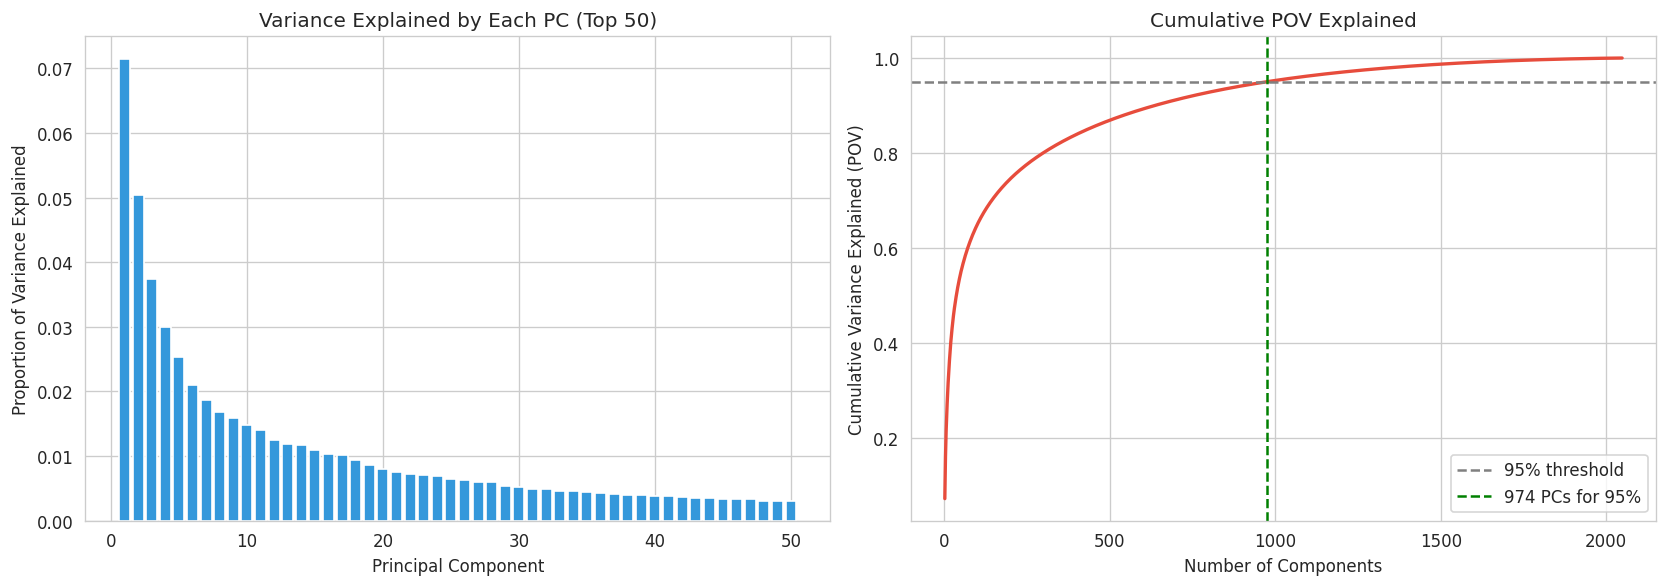

Components needed for 95% variance: 974


In [10]:
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_train_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual variance per component (top 50)
axes[0].bar(range(1, 51), pca_full.explained_variance_ratio_[:50], color='#3498db')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Proportion of Variance Explained")
axes[0].set_title("Variance Explained by Each PC (Top 50)")

# Right: cumulative POV
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, color='#e74c3c', lw=2)
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
n95 = np.argmax(cumulative_var >= 0.95) + 1
axes[1].axvline(x=n95, color='green', linestyle='--', label=f'{n95} PCs for 95%')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance Explained (POV)")
axes[1].set_title("Cumulative POV Explained")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Components needed for 95% variance: {n95}")

## PCA - 2D Feature Visualization

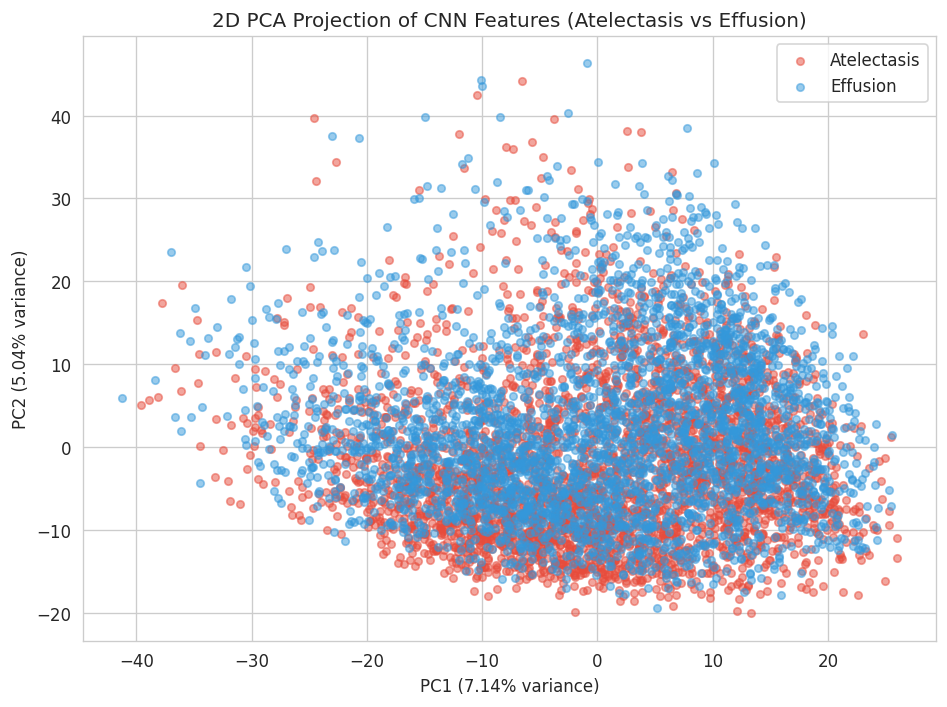

PC1 variance: 0.0714
PC2 variance: 0.0504
Total (2 PCs): 0.1218


In [11]:
pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
for label, color in zip([0, 1], ['#e74c3c', '#3498db']):
    mask = y_train == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=color, label=le.classes_[label], alpha=0.5, s=20)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)")
plt.title("2D PCA Projection of CNN Features (Atelectasis vs Effusion)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"PC1 variance: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"PC2 variance: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total (2 PCs): {sum(pca_2d.explained_variance_ratio_):.4f}")

## Apply PCA (974 Components)

In [12]:
pca = PCA(n_components=974, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features:  {X_train_scaled.shape[1]}")
print(f"PCA features:       {X_train_pca.shape[1]}")
print(f"Variance retained:  {sum(pca.explained_variance_ratio_):.4f}")

Original features:  2048
PCA features:       974
Variance retained:  0.9489


## Train SVM on PCA Features

In [13]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
                random_state=RANDOM_SEED, probability=True)

print("Training SVM on PCA features...")
start = time.time()
svm_model.fit(X_train_pca, y_train)
print(f"Done in {(time.time()-start):.1f} sec")

y_pred_svm = svm_model.predict(X_test_pca)
y_scores_svm = svm_model.decision_function(X_test_pca)

print("\n--- SVM Results (PCA features) ---")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))
print(f"AUC: {roc_auc_score(y_test, y_scores_svm):.4f}")

Training SVM on PCA features...
Done in 118.6 sec

--- SVM Results (PCA features) ---
              precision    recall  f1-score   support

 Atelectasis       0.72      0.71      0.72       843
    Effusion       0.70      0.71      0.70       791

    accuracy                           0.71      1634
   macro avg       0.71      0.71      0.71      1634
weighted avg       0.71      0.71      0.71      1634

AUC: 0.7880


## Train KNN (K=1) on PCA Features

In [14]:
knn1 = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)

print("Training KNN (k=1) on PCA features...")
start = time.time()
knn1.fit(X_train_pca, y_train)
print(f"Done in {(time.time()-start):.1f} sec")

y_pred_knn1 = knn1.predict(X_test_pca)
y_scores_knn1 = knn1.predict_proba(X_test_pca)[:, 1]

print("\n--- KNN (k=1) Results (PCA features) ---")
print(classification_report(y_test, y_pred_knn1, target_names=le.classes_))
print(f"AUC: {roc_auc_score(y_test, y_scores_knn1):.4f}")

Training KNN (k=1) on PCA features...
Done in 0.0 sec

--- KNN (k=1) Results (PCA features) ---
              precision    recall  f1-score   support

 Atelectasis       0.64      0.69      0.66       843
    Effusion       0.64      0.60      0.62       791

    accuracy                           0.64      1634
   macro avg       0.64      0.64      0.64      1634
weighted avg       0.64      0.64      0.64      1634

AUC: 0.6412


## Train KNN (K=27) on PCA Features

In [15]:
knn27 = KNeighborsClassifier(n_neighbors=27, n_jobs=-1)

print("Training KNN (k=27) on PCA features...")
start = time.time()
knn27.fit(X_train_pca, y_train)
print(f"Done in {(time.time()-start):.1f} sec")

y_pred_knn27 = knn27.predict(X_test_pca)
y_scores_knn27 = knn27.predict_proba(X_test_pca)[:, 1]

print("\n--- KNN (k=27) Results (PCA features) ---")
print(classification_report(y_test, y_pred_knn27, target_names=le.classes_))
print(f"AUC: {roc_auc_score(y_test, y_scores_knn27):.4f}")

Training KNN (k=27) on PCA features...
Done in 0.0 sec

--- KNN (k=27) Results (PCA features) ---
              precision    recall  f1-score   support

 Atelectasis       0.65      0.78      0.71       843
    Effusion       0.70      0.55      0.62       791

    accuracy                           0.67      1634
   macro avg       0.67      0.66      0.66      1634
weighted avg       0.67      0.67      0.66      1634

AUC: 0.7329


## Confusion Matrices - All Models

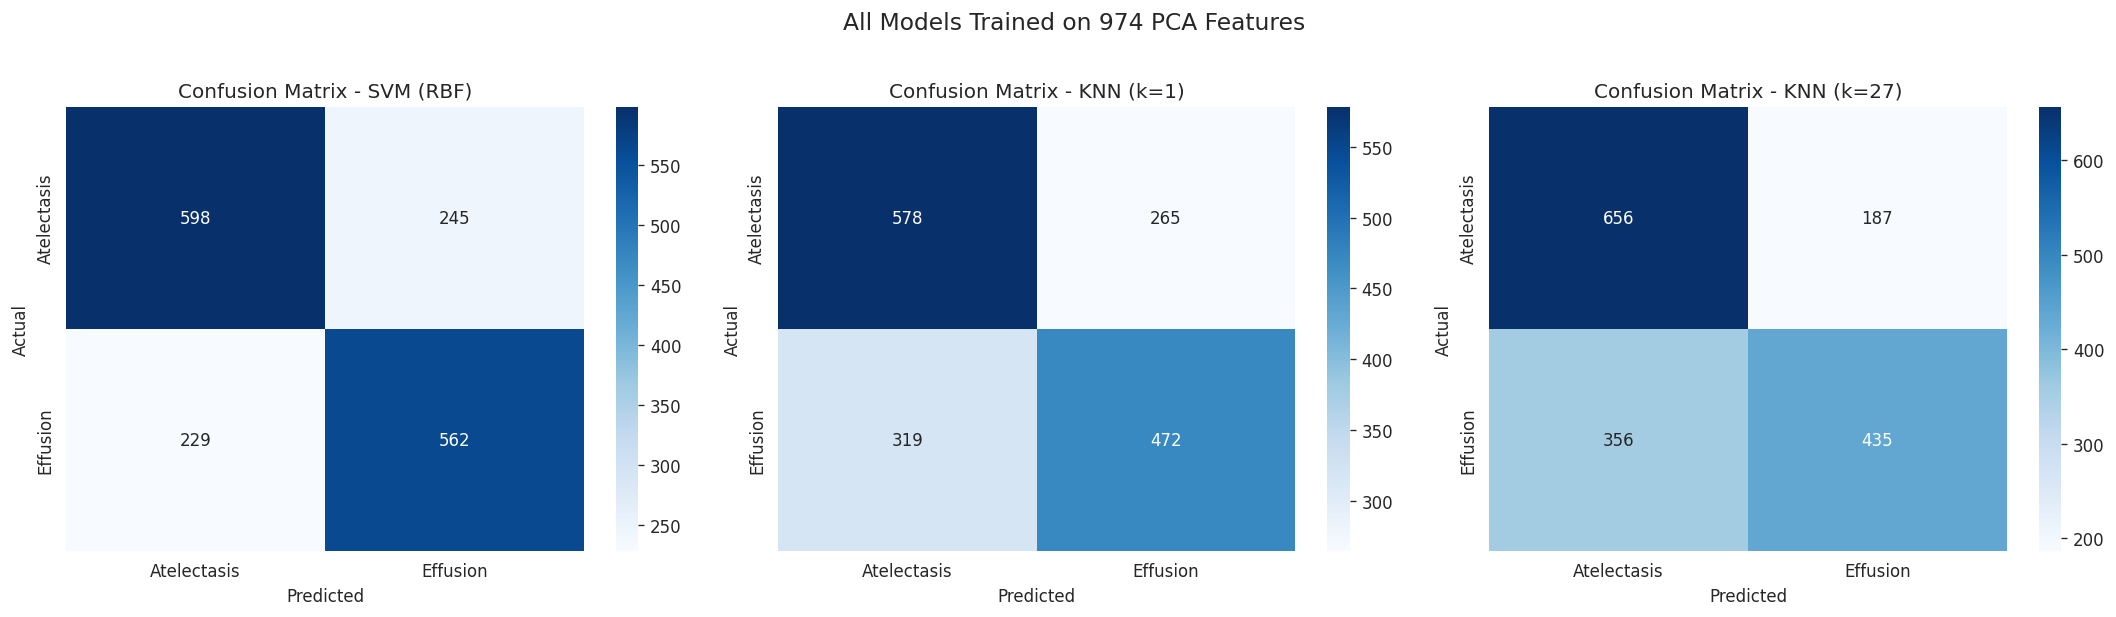

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(axes,
    [y_pred_svm, y_pred_knn1, y_pred_knn27],
    ["SVM (RBF)", "KNN (k=1)", "KNN (k=27)"]):

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {title}")

plt.suptitle("All Models Trained on 974 PCA Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## ROC Curves - Model Comparison

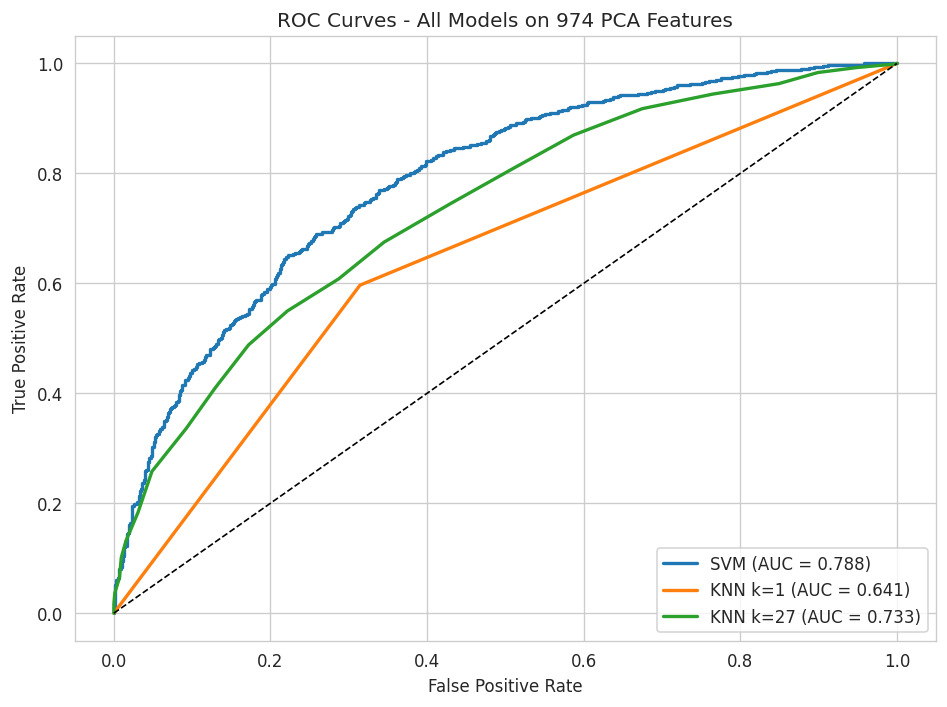

In [17]:
plt.figure(figsize=(8, 6))

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_scores_svm)
fpr_knn1, tpr_knn1, _ = roc_curve(y_test, y_scores_knn1)
fpr_knn27, tpr_knn27, _ = roc_curve(y_test, y_scores_knn27)

auc_svm = roc_auc_score(y_test, y_scores_svm)
auc_knn1 = roc_auc_score(y_test, y_scores_knn1)
auc_knn27 = roc_auc_score(y_test, y_scores_knn27)

plt.plot(fpr_svm, tpr_svm, lw=2, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_knn1, tpr_knn1, lw=2, label=f"KNN k=1 (AUC = {auc_knn1:.3f})")
plt.plot(fpr_knn27, tpr_knn27, lw=2, label=f"KNN k=27 (AUC = {auc_knn27:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models on 974 PCA Features")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Overall Metrics Comparison

In [18]:
results = []

for name, y_pred, y_scores in [
    ("SVM (RBF)", y_pred_svm, y_scores_svm),
    ("KNN (k=1)", y_pred_knn1, y_scores_knn1),
    ("KNN (k=27)", y_pred_knn27, y_scores_knn27)
]:
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average='macro'),
        "Recall (macro)": recall_score(y_test, y_pred, average='macro'),
        "F1 (macro)": f1_score(y_test, y_pred, average='macro'),
        "AUC": roc_auc_score(y_test, y_scores)
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.round(4)
print("=" * 70)
print("         Overall Metrics — All Models (974 PCA Features)")
print("=" * 70)
print(results_df.to_string())

         Overall Metrics — All Models (974 PCA Features)
            Accuracy  Precision (macro)  Recall (macro)  F1 (macro)     AUC
Model                                                                      
SVM (RBF)     0.7099             0.7098          0.7099      0.7098  0.7880
KNN (k=1)     0.6426             0.6424          0.6412      0.6411  0.6412
KNN (k=27)    0.6677             0.6738          0.6641      0.6615  0.7329
